# 02 Temperature Stress Bifurcation

Hotfish morphology and sequencing latent-space bifurcation plots from centralized cache.


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from figure_utils import (
    CACHE_DIR,
    FIG_DIR,
    EXCLUDED_TEMPERATURES,
    add_identity,
    drop_excluded_temperatures,
    is_included_temperature,
    plot_heatmap_matrix,
    plot_temperature_variability_bootstrap,
    savefig,
    set_light_style,
    temperature_timepoint_scatter,
    timepoint_average_variability_bootstrap,
    value_timepoint_scatter,
)
set_light_style()
print(CACHE_DIR)
print(FIG_DIR)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


/Users/nick/Projects/data/morphseq/results/20260528
/Users/nick/Projects/data/morphseq/results/20260528/figures_no19C_timepoint


In [2]:

hf = drop_excluded_temperatures(pd.read_csv(CACHE_DIR / 'hf_pca_morph_df_with_spline_distance.csv'))
hf_hooke = drop_excluded_temperatures(pd.read_csv(CACHE_DIR / 'hf_pca_morph_df_hooke.csv'))
ref = pd.read_csv(CACHE_DIR / 'ab_ref_pca_morph_df.csv')
spline_morph = pd.read_csv(CACHE_DIR / 'spline_morph_df.csv')
hf_seq = pd.read_csv(CACHE_DIR / 'hf_seq_df.csv')
spline_seq = pd.read_csv(CACHE_DIR / 'spline_seq_df.csv')
seq_meta = drop_excluded_temperatures(pd.read_csv(CACHE_DIR / 'joint_141_morph_seq.csv'))[['sample', 'temperature', 'timepoint', 'snip_id']]
manifest = pd.read_csv(CACHE_DIR / 'source_manifest.csv')
print(f'Excluded temperatures: {EXCLUDED_TEMPERATURES}')


Excluded temperatures: (19.0,)


## 2.a Morphology PCA plot for hotfish embryos plus WT reference spline


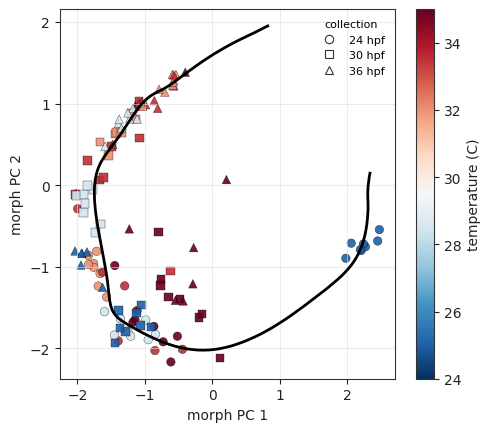

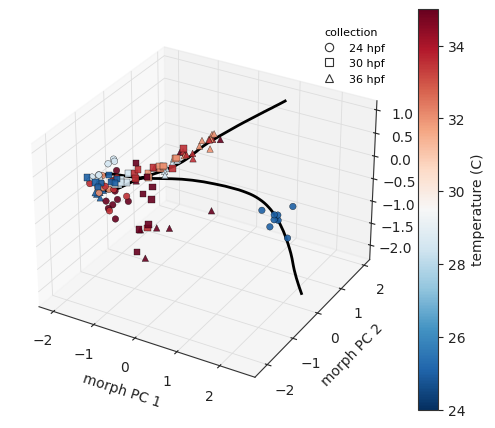

In [3]:

fig, ax = plt.subplots(figsize=(5.4, 4.8))
temperature_timepoint_scatter(ax, hf['PCA_00_bio'], hf['PCA_01_bio'], hf['temperature'], hf['timepoint'], s=38, alpha=0.9)
ax.plot(spline_morph['PCA_00_bio'], spline_morph['PCA_01_bio'], color='black', lw=2, label='WT spline')
ax.set_xlabel('morph PC 1')
ax.set_ylabel('morph PC 2')
savefig(fig, '02a_morph_pca_2d_with_wt_spline')
plt.show()

fig = plt.figure(figsize=(6.2, 5.2))
ax = fig.add_subplot(111, projection='3d')
temperature_timepoint_scatter(
    ax,
    hf['PCA_00_bio'],
    hf['PCA_01_bio'],
    hf['temperature'],
    hf['timepoint'],
    z=hf['PCA_02_bio'],
    s=22,
)
ax.plot(spline_morph['PCA_00_bio'], spline_morph['PCA_01_bio'], spline_morph['PCA_02_bio'], color='black', lw=2)
ax.set_xlabel('morph PC 1'); ax.set_ylabel('morph PC 2'); ax.set_zlabel('morph PC 3')
savefig(fig, '02a_morph_pca_3d_with_wt_spline')
plt.show()


## 2.b Morphology PCA with individual WT reference embryo trajectories


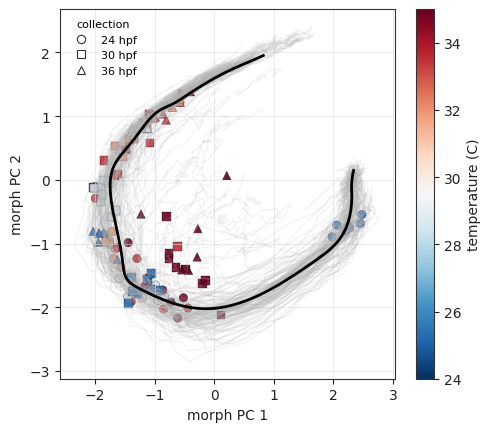

In [4]:

fig, ax = plt.subplots(figsize=(5.4, 4.8))
for _, grp in ref.groupby('embryo_id'):
    ax.plot(grp['PCA_00_bio'], grp['PCA_01_bio'], color='0.7', alpha=0.18, lw=0.8)
temperature_timepoint_scatter(ax, hf['PCA_00_bio'], hf['PCA_01_bio'], hf['temperature'], hf['timepoint'], s=38, alpha=0.9)
ax.plot(spline_morph['PCA_00_bio'], spline_morph['PCA_01_bio'], color='black', lw=2)
ax.set_xlabel('morph PC 1')
ax.set_ylabel('morph PC 2')
savefig(fig, '02b_morph_pca_2d_with_reference_embryos')
plt.show()


## 2.c Sequencing latent-space version with WT spline


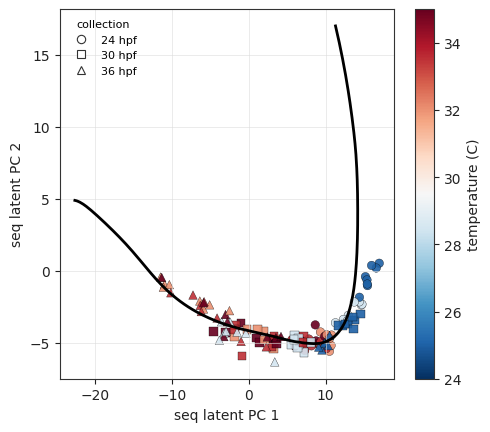

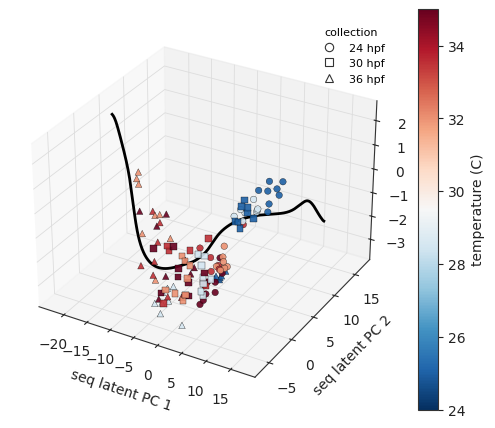

In [5]:

seq_plot = (
    hf_seq.rename(columns={hf_seq.columns[0]: 'sample'})
    .merge(seq_meta, on='sample', how='inner', validate='one_to_one')
)
if len(seq_plot) != len(seq_meta):
    missing = sorted(set(seq_meta['sample']) - set(seq_plot['sample']))
    print(f'Warning: {len(missing)} sequence metadata rows were not found in hf_seq_df: {missing[:5]}')
fig, ax = plt.subplots(figsize=(5.4, 4.8))
temperature_timepoint_scatter(ax, seq_plot['PCA_00'], seq_plot['PCA_01'], seq_plot['temperature'], seq_plot['timepoint'], s=38, alpha=0.9)
ax.plot(spline_seq['PCA_00'], spline_seq['PCA_01'], color='black', lw=2, label='WT spline')
ax.set_xlabel('seq latent PC 1')
ax.set_ylabel('seq latent PC 2')
savefig(fig, '02c_seq_pca_2d_with_wt_spline')
plt.show()

fig = plt.figure(figsize=(6.2, 5.2))
ax = fig.add_subplot(111, projection='3d')
temperature_timepoint_scatter(
    ax,
    seq_plot['PCA_00'],
    seq_plot['PCA_01'],
    seq_plot['temperature'],
    seq_plot['timepoint'],
    z=seq_plot['PCA_02'],
    s=22,
)
ax.plot(spline_seq['PCA_00'], spline_seq['PCA_01'], spline_seq['PCA_02'], color='black', lw=2)
ax.set_xlabel('seq latent PC 1'); ax.set_ylabel('seq latent PC 2'); ax.set_zlabel('seq latent PC 3')
savefig(fig, '02c_seq_pca_3d_with_wt_spline')
plt.show()


## 2.d Sequencing latent-space with individual WT references

Independent WT reference sequencing trajectories were not found as a cached table; this notebook records that as unavailable and shows the WT spline only.


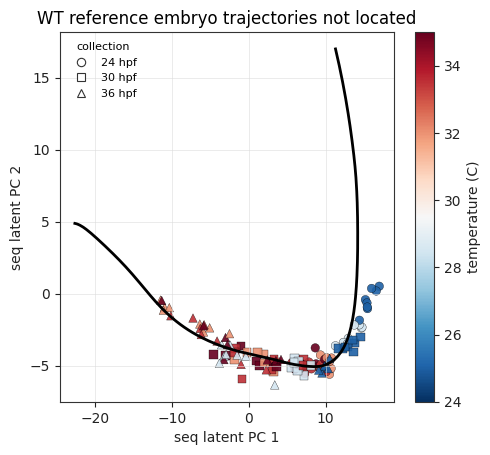

In [6]:

fig, ax = plt.subplots(figsize=(5.4, 4.8))
temperature_timepoint_scatter(ax, seq_plot['PCA_00'], seq_plot['PCA_01'], seq_plot['temperature'], seq_plot['timepoint'], s=38, alpha=0.9)
ax.plot(spline_seq['PCA_00'], spline_seq['PCA_01'], color='black', lw=2)
ax.set_xlabel('seq latent PC 1')
ax.set_ylabel('seq latent PC 2')
ax.set_title('WT reference embryo trajectories not located')
savefig(fig, '02d_seq_pca_reference_spline_only')
plt.show()


## 2.e Morphology PCA colored by distance from WT spline


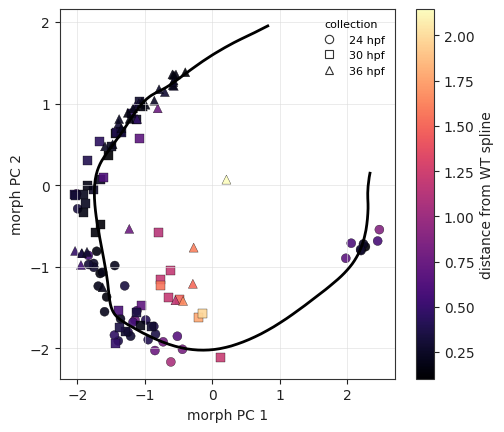

In [7]:

fig, ax = plt.subplots(figsize=(5.4, 4.8))
value_timepoint_scatter(
    ax,
    hf['PCA_00_bio'],
    hf['PCA_01_bio'],
    hf['morph_dist_spline'],
    hf['timepoint'],
    cmap='magma',
    colorbar_label='distance from WT spline',
    s=42,
)
ax.plot(spline_morph['PCA_00_bio'], spline_morph['PCA_01_bio'], color='black', lw=2)
ax.set_xlabel('morph PC 1')
ax.set_ylabel('morph PC 2')
savefig(fig, '02e_morph_pca_distance_from_wt_spline')
plt.show()


## 2.f Volcano plot for curved vs normal cell type abundance differences


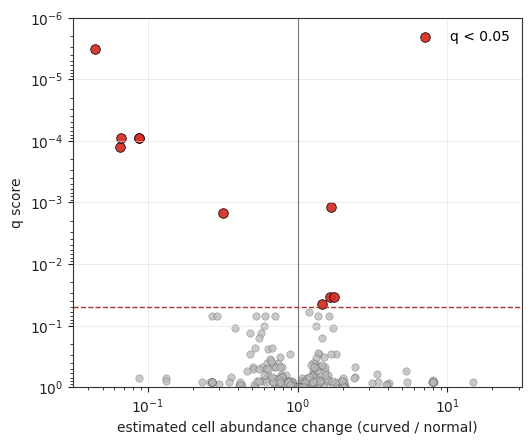

In [8]:
volcano_path = CACHE_DIR / 'hotfish_morph_ccs_contrast.csv'
if volcano_path.exists():
    volcano = pd.read_csv(volcano_path)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    delta_log = pd.to_numeric(volcano.get('delta_log_abund', volcano.iloc[:, 1]), errors='coerce')
    # Match the original Plotly orientation: abundance fold-change for branched/curved vs normal.
    x = np.exp(-delta_log)
    q = pd.to_numeric(volcano.get('delta_q_value', volcano.iloc[:, -1]), errors='coerce').clip(lower=1e-300)
    sig = q < 0.05

    ax.scatter(x[~sig], q[~sig], s=28, color='0.72', edgecolor='0.35', linewidth=0.3, alpha=0.75)
    ax.scatter(x[sig], q[sig], s=48, color='#d73027', edgecolor='black', linewidth=0.55, alpha=0.95, label='q < 0.05')
    ax.axvline(1, color='0.45', ls='-', lw=0.8)
    ax.axhline(0.05, color='#aa3333', ls='--', lw=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(10**-1.5, 10**1.5)
    ax.set_ylim(1, 1e-6)
    ax.set_xlabel('estimated cell abundance change (curved / normal)')
    ax.set_ylabel('q score')
    ax.legend(frameon=False, loc='upper right')
    savefig(fig, '02f_curved_vs_normal_cell_type_volcano')
    plt.show()
else:
    print('Missing volcano source:', volcano_path)
    print(manifest.loc[manifest['analysis_name'] == 'curved_vs_normal_cell_type_volcano'].to_string(index=False))
